In [1]:
import os
import json
import shutil
import random
from pathlib import Path
import yaml
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import albumentations as A
from albumentations import Compose, BboxParams

In [2]:
# ============================================================
# Configuration
# ============================================================
DATASET_ROOT = "/kaggle/input/datasets/sumn2u/conveyor-belt-recyclables-dataset"
CLASS_NAMES = ["cardboard", "glass", "metal", "paper", "plastic"]   # adjust to your actual classes
WORKING_ROOT = "/kaggle/working/recyclables_dataset_augmented"
AUG_SUFFIX = "_aug"

In [3]:
# ============================================================
# Collect One Random Image From Each Class
# ============================================================
samples = []

DATASET_ROOT_PATH = Path("/kaggle/input/datasets/sumn2u/conveyor-belt-recyclables-dataset")

for class_name in CLASS_NAMES:

    images_dir = DATASET_ROOT_PATH / class_name / "images"
    labels_dir = DATASET_ROOT_PATH / class_name / "labels"

    image_files = list(images_dir.glob("*"))

    if len(image_files) == 0:
        continue

    # Pick one random image
    image_path = random.choice(image_files)

    # Corresponding YOLO label
    label_path = labels_dir / f"{image_path.stem}.txt"

    samples.append((class_name, image_path, label_path))



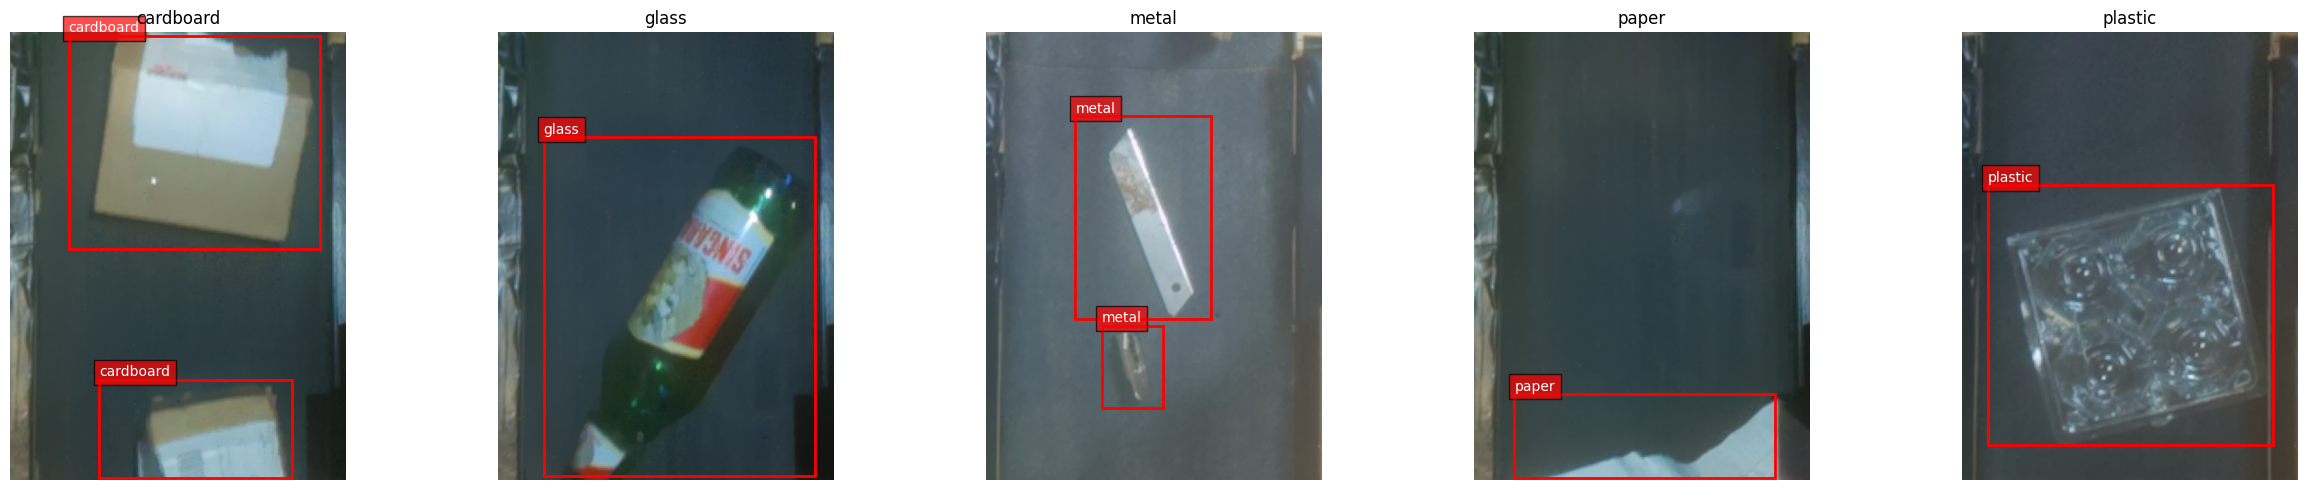

In [4]:
# ============================================================
# Plot Images
# ============================================================
fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))

if len(samples) == 1:
    axes = [axes]

for ax, (class_name, image_path, label_path) in zip(axes, samples):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w, _ = image.shape

    ax.imshow(image)

    # Draw annotations
    if label_path.exists():

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            class_id, x_center, y_center, bw, bh = map(float, line.strip().split())

            # YOLO -> pixel coordinates
            x_center *= w
            y_center *= h
            bw *= w
            bh *= h

            x1 = x_center - bw / 2
            y1 = y_center - bh / 2

            # Bounding box
            rect = patches.Rectangle(
                (x1, y1),
                bw,
                bh,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )

            ax.add_patch(rect)

            # Class name
            ax.text(
                x1,
                y1 - 5,
                CLASS_NAMES[int(class_id)],
                color="white",
                fontsize=10,
                bbox=dict(facecolor="red", alpha=0.7)
            )

    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()



In [5]:
# ============================================================
# Save Figure
# ============================================================
SAVE_PATH = "/kaggle/working/random_samples_with_annotations.png"
plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")

print(f"Saved to: {SAVE_PATH}")

plt.show()

Saved to: /kaggle/working/random_samples_with_annotations.png


<Figure size 640x480 with 0 Axes>

In [6]:
# ============================================================
# Augmentation pipelines for each version
# ============================================================
def get_augmentation_pipeline(version):
    """
    Returns a fixed augmentation pipeline for the given version.
    version: 1 -> horizontal flip only
             2 -> brightness/contrast only
    """
    if version == 1:
        # Horizontal flip (always applied, not random)
        return Compose([A.HorizontalFlip(p=1.0)], 
                       bbox_params=BboxParams(format='yolo', label_fields=['class_labels']))
    elif version == 2:
        # Brightness/contrast adjustment (always applied)
        return Compose([
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.3, p=1.0),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.7)
            ], bbox_params=BboxParams(format='yolo', label_fields=['class_labels']))
    else:
        raise ValueError(f"Unknown version {version}")

def apply_augmentation(image, bboxes_yolo, class_ids, version):
    """Apply version-specific augmentation."""
    pipeline = get_augmentation_pipeline(version)
    augmented = pipeline(image=image, bboxes=bboxes_yolo, class_labels=class_ids)
    return augmented['image'], augmented['bboxes'], augmented['class_labels']

# ============================================================
# Helper functions
# ============================================================
def augment_and_save(image_path, label_path, output_img_path, output_label_path, version):
    """Load image/label, apply version-specific augmentation, save result."""
    img = cv2.imread(image_path)
    if img is None:
        return False
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Load YOLO labels
    bboxes_yolo = []
    class_ids = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id, x_c, y_c, w_n, h_n = map(float, parts)
                bboxes_yolo.append([x_c, y_c, w_n, h_n])
                class_ids.append(int(cls_id))
    
    # Apply augmentation
    if len(bboxes_yolo) > 0:
        aug_img, aug_bboxes, aug_class_ids = apply_augmentation(img_rgb, bboxes_yolo, class_ids, version)
    else:
        pipeline = get_augmentation_pipeline(version)
        augmented = pipeline(image=img_rgb, bboxes=[], class_labels=[])
        aug_img = augmented['image']
        aug_bboxes = []
        aug_class_ids = []
    
    # Convert back to BGR for saving
    aug_img_bgr = cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(output_img_path, aug_img_bgr)
    
    # Save YOLO labels
    with open(output_label_path, 'w') as f:
        for (x_c, y_c, w_n, h_n), cls_id in zip(aug_bboxes, aug_class_ids):
            f.write(f"{cls_id} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}\n")
    return True

def draw_yolo_bboxes(image_path, label_path, class_names):
    img = cv2.imread(image_path)
    if img is None:
        return None
    h, w = img.shape[:2]
    if not os.path.exists(label_path):
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, x_c, y_c, w_n, h_n = map(float, parts)
            x1 = int((x_c - w_n/2) * w)
            y1 = int((y_c - h_n/2) * h)
            x2 = int((x_c + w_n/2) * w)
            y2 = int((y_c + h_n/2) * h)
            x1 = max(0, min(x1, w-1))
            y1 = max(0, min(y1, h-1))
            x2 = max(0, min(x2, w-1))
            y2 = max(0, min(y2, h-1))
            label = class_names[int(cls_id)] if int(cls_id) < len(class_names) else str(int(cls_id))
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def find_category_pairs(root_dir):
    """Find all original (non-augmented) image-label pairs."""
    pairs = []
    for category in os.listdir(root_dir):
        cat_path = os.path.join(root_dir, category)
        if not os.path.isdir(cat_path):
            continue
        images_dir = os.path.join(cat_path, "images")
        labels_dir = os.path.join(cat_path, "labels")
        if not (os.path.exists(images_dir) and os.path.exists(labels_dir)):
            continue
        for img_file in os.listdir(images_dir):
            if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            # Skip already augmented images
            if AUG_SUFFIX in Path(img_file).stem:
                continue
            base = Path(img_file).stem
            label_file = base + ".txt"
            label_path = os.path.join(labels_dir, label_file)
            img_path = os.path.join(images_dir, img_file)
            pairs.append((img_path, label_path, category))
    return pairs

def generate_augmented_copies(root_dir):
    """For each original image, create two augmented copies: flip (v1) and lighting (v2)."""
    print("Generating augmented copies...")
    original_pairs = find_category_pairs(root_dir)
    print(f"Found {len(original_pairs)} original images.")
    for img_path, label_path, category in original_pairs:
        base = Path(img_path).stem
        img_dir = os.path.dirname(img_path)
        label_dir = os.path.dirname(label_path)
        
        # Version 1: horizontal flip
        v1_img_file = f"{base}{AUG_SUFFIX}1{Path(img_path).suffix}"
        v1_label_file = f"{base}{AUG_SUFFIX}1.txt"
        v1_img_path = os.path.join(img_dir, v1_img_file)
        v1_label_path = os.path.join(label_dir, v1_label_file)
        if not os.path.exists(v1_img_path):
            augment_and_save(img_path, label_path, v1_img_path, v1_label_path, version=1)
        
        # Version 2: brightness/contrast (lighting)
        v2_img_file = f"{base}{AUG_SUFFIX}2{Path(img_path).suffix}"
        v2_label_file = f"{base}{AUG_SUFFIX}2.txt"
        v2_img_path = os.path.join(img_dir, v2_img_file)
        v2_label_path = os.path.join(label_dir, v2_label_file)
        if not os.path.exists(v2_img_path):
            augment_and_save(img_path, label_path, v2_img_path, v2_label_path, version=2)
    
    print("Augmented copies generated.")

def create_coco_json(root_dir, class_names, output_json):
    """Create COCO JSON from all images (original + augmented)."""
    coco = {
        "images": [],
        "annotations": [],
        "categories": [{"id": i, "name": name, "supercategory": "object"} for i, name in enumerate(class_names)]
    }
    ann_id = 1
    image_id = 1
    for category in os.listdir(root_dir):
        cat_path = os.path.join(root_dir, category)
        if not os.path.isdir(cat_path):
            continue
        images_dir = os.path.join(cat_path, "images")
        labels_dir = os.path.join(cat_path, "labels")
        if not os.path.exists(images_dir):
            continue
        for img_file in os.listdir(images_dir):
            if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img_path = os.path.join(images_dir, img_file)
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
            except:
                continue
            coco["images"].append({
                "id": image_id,
                "file_name": os.path.join(category, "images", img_file),
                "width": width,
                "height": height
            })
            label_file = Path(img_file).stem + ".txt"
            label_path = os.path.join(labels_dir, label_file)
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) != 5:
                            continue
                        cls_id, x_c, y_c, w_n, h_n = map(float, parts)
                        x = (x_c - w_n/2) * width
                        y = (y_c - h_n/2) * height
                        w_abs = w_n * width
                        h_abs = h_n * height
                        x = max(0, min(x, width-1))
                        y = max(0, min(y, height-1))
                        w_abs = max(1, min(w_abs, width - x))
                        h_abs = max(1, min(h_abs, height - y))
                        coco["annotations"].append({
                            "id": ann_id, "image_id": image_id, "category_id": int(cls_id),
                            "bbox": [x, y, w_abs, h_abs], "area": w_abs * h_abs, "iscrowd": 0
                        })
                        ann_id += 1
            image_id += 1
    with open(output_json, 'w') as f:
        json.dump(coco, f, indent=2)
    print(f"COCO JSON saved: {output_json} (images: {image_id-1}, annotations: {ann_id-1})")

def preview_augmentation(root_dir, class_names, num_samples=3):
    """Display original + flip (v1) + lighting (v2) side by side for random samples."""
    original_pairs = find_category_pairs(root_dir)
    if not original_pairs:
        print("No original images found.")
        return
    print(f"Found {len(original_pairs)} original images. Showing up to {num_samples} samples.")
    samples = random.sample(original_pairs, min(num_samples, len(original_pairs)))
    
    fig, axes = plt.subplots(len(samples), 3, figsize=(12, 4*len(samples)))
    if len(samples) == 1:
        axes = axes.reshape(1, -1)
    
    for i, (img_path, label_path, category) in enumerate(samples):
        base = Path(img_path).stem
        img_dir = os.path.dirname(img_path)
        label_dir = os.path.dirname(label_path)
        
        # Original
        orig_rgb = draw_yolo_bboxes(img_path, label_path, class_names)
        axes[i, 0].imshow(orig_rgb)
        axes[i, 0].set_title(f"Original: {Path(img_path).name}", fontsize=10)
        axes[i, 0].axis('off')
        
        # Flip version (v1)
        v1_img_file = f"{base}{AUG_SUFFIX}1{Path(img_path).suffix}"
        v1_img_path = os.path.join(img_dir, v1_img_file)
        v1_label_path = os.path.join(label_dir, f"{base}{AUG_SUFFIX}1.txt")
        if not os.path.exists(v1_img_path):
            augment_and_save(img_path, label_path, v1_img_path, v1_label_path, version=1)
        v1_rgb = draw_yolo_bboxes(v1_img_path, v1_label_path, class_names)
        axes[i, 1].imshow(v1_rgb)
        axes[i, 1].set_title("Augmented: Flip", fontsize=10)
        axes[i, 1].axis('off')
        
        # Lighting version (v2)
        v2_img_file = f"{base}{AUG_SUFFIX}2{Path(img_path).suffix}"
        v2_img_path = os.path.join(img_dir, v2_img_file)
        v2_label_path = os.path.join(label_dir, f"{base}{AUG_SUFFIX}2.txt")
        if not os.path.exists(v2_img_path):
            augment_and_save(img_path, label_path, v2_img_path, v2_label_path, version=2)
        v2_rgb = draw_yolo_bboxes(v2_img_path, v2_label_path, class_names)
        axes[i, 2].imshow(v2_rgb)
        axes[i, 2].set_title("Augmented: Lighting", fontsize=10)
        axes[i, 2].axis('off')
    
    # plt.suptitle("Original vs Horizontal Flip vs Lighting Change", fontsize=14)
    plt.tight_layout()
    plt.show()

Copying dataset from /kaggle/input/datasets/sumn2u/conveyor-belt-recyclables-dataset to /kaggle/working/recyclables_dataset_augmented ...
Copy completed.
Generating augmented copies...
Found 293 original images.


/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


Augmented copies generated.
COCO JSON saved: /kaggle/working/recyclables_dataset_augmented/annotations_coco.json (images: 879, annotations: 1020)
Found 293 original images. Showing up to 10 samples.


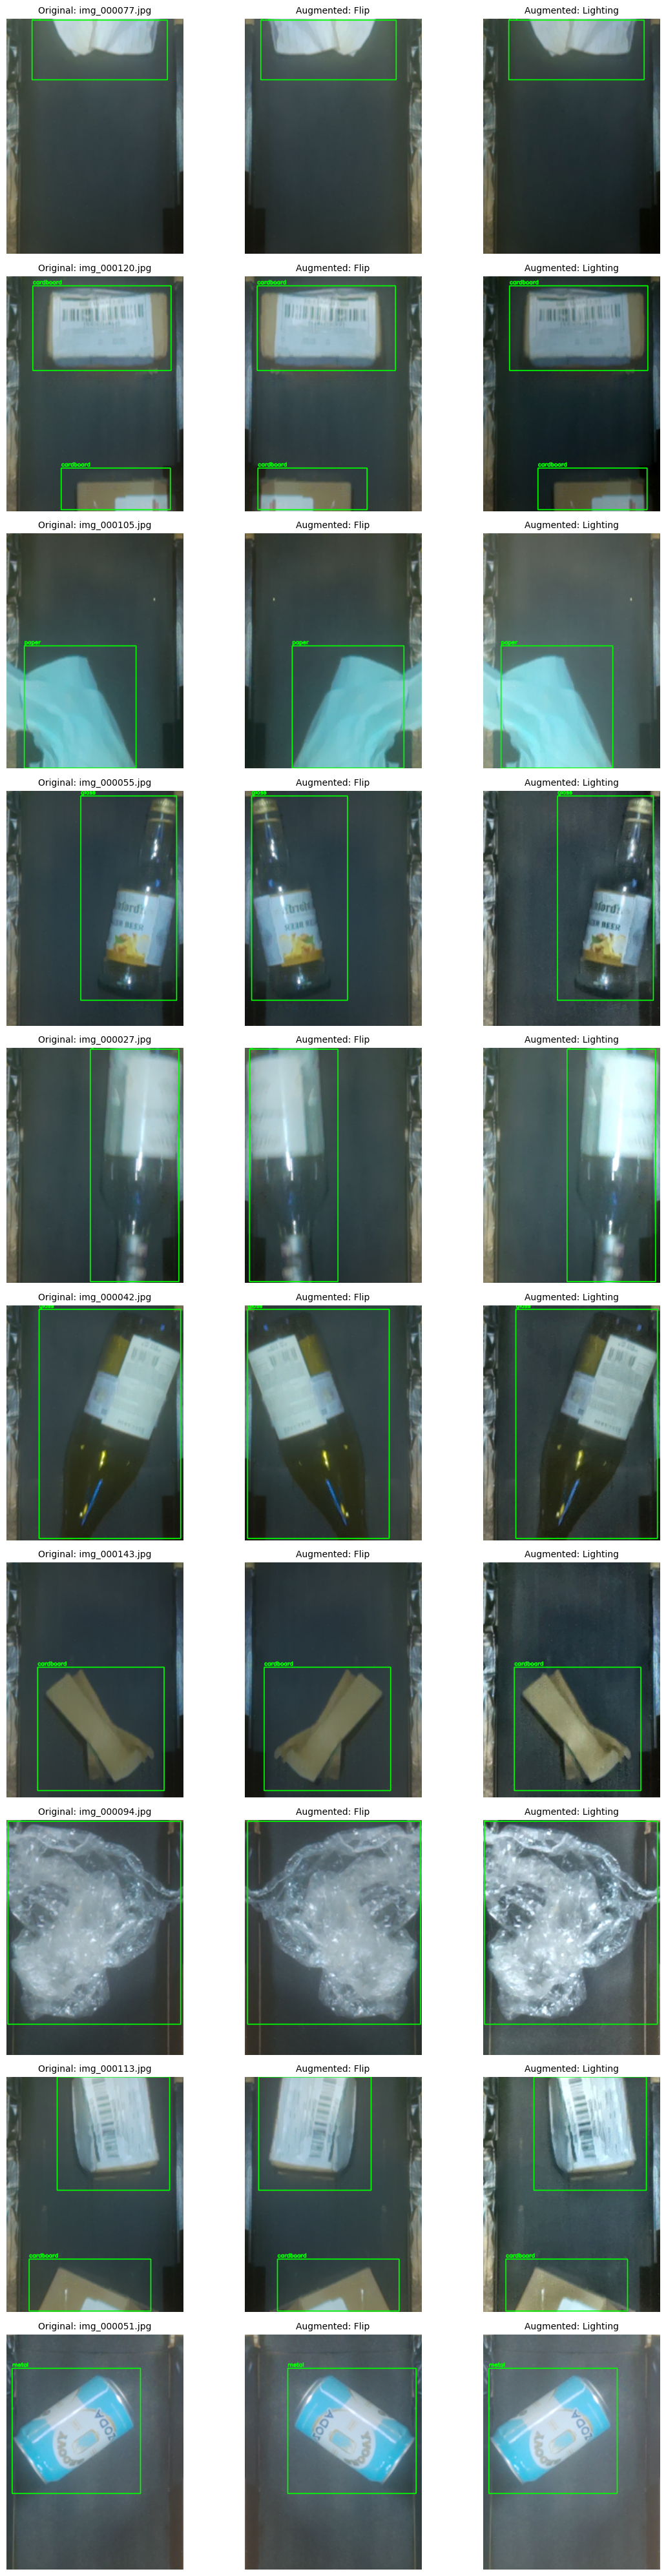


✅ Done. Augmented dataset saved in /kaggle/working/recyclables_dataset_augmented
   - Version 1: horizontal flip (suffix _aug1)
   - Version 2: brightness/contrast lighting (suffix _aug2)
   COCO annotations: /kaggle/working/recyclables_dataset_augmented/annotations_coco.json


In [7]:
# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # Copy dataset to writable location if needed
    if not os.path.exists(WORKING_ROOT):
        print(f"Copying dataset from {DATASET_ROOT} to {WORKING_ROOT} ...")
        shutil.copytree(DATASET_ROOT, WORKING_ROOT)
        print("Copy completed.")
    else:
        print(f"Using existing working directory: {WORKING_ROOT}")
    
    # Generate two distinct augmented copies per original
    generate_augmented_copies(WORKING_ROOT)
    
    # Create COCO JSON including all images
    output_json = os.path.join(WORKING_ROOT, "annotations_coco.json")
    create_coco_json(WORKING_ROOT, CLASS_NAMES, output_json)
    
    # Preview original, flip, lighting side by side
    preview_augmentation(WORKING_ROOT, CLASS_NAMES, num_samples=10)
    
    print(f"\n✅ Done. Augmented dataset saved in {WORKING_ROOT}")
    print(f"   - Version 1: horizontal flip (suffix _aug1)")
    print(f"   - Version 2: brightness/contrast lighting (suffix _aug2)")
    print(f"   COCO annotations: {output_json}")